<a href="https://colab.research.google.com/github/lurkz13/Algoritmos_de_optimizacion/blob/main/Copia_de_Trabajo_Pr%C3%A1ctico_Lander_Urkitza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Lander Urkitza Irazabal <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/xxxxxxxxxxxxxxxx <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:(copiar enunciado)

....







                                        

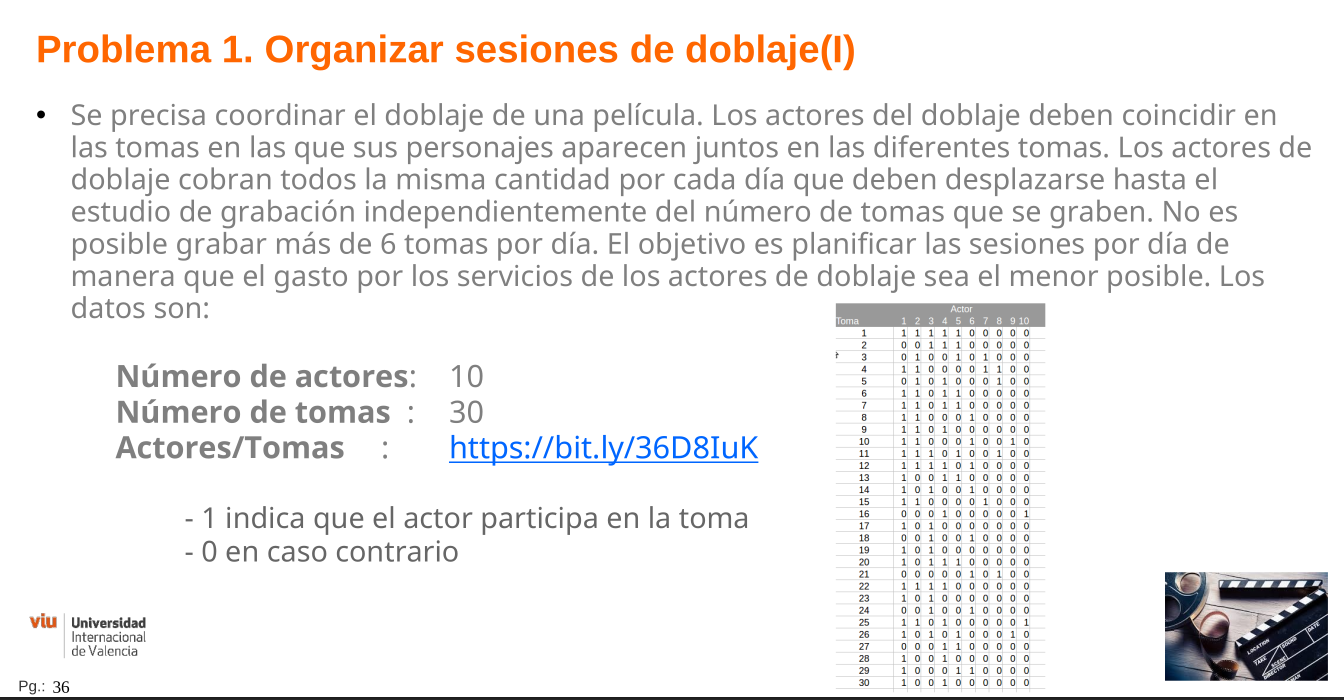

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

**¿Como represento el espacio de soluciones?**

El espacio de soluciones se muestra como un calendario de rodaje que está organizado por conjuntos. Cada toma es un conjunto y contiene un número distinto de elementos que son los índices de los actores que participan en ella.


**¿Cual es la función objetivo?**

La función objetivo es minimizar el gasto total por el servicio de los actores en todo el calendario. Concretamente se busca minimizar la variable mejor_coste evaluando el coste_actual. Al mismo tiempo se evalua si interesa añadir una toma más el mismo día o por el contrario abrir un día nuevo.


**¿Como implemento las restricciones?**

La restricción que muestra el enunciado es que no se puden grabar más de 6 tomas en un mismo día

#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

El problema es de tipo NP-Hard de optimización combinatoria. Se parte de 30 tomas y se debe contruir el árbol completo de todos los casos. Es de una complejidad muy elevada del orden de facotrial o exponencial. Por otro lado el espacio de soluciones explorado está limitado por la restricción de la grabación de 6 tomas al día y la poda realziada.

#Diseño
- ¿Que técnica utilizo? ¿Por qué?

Se utiliza la técnica del **Backtracking** estructurada como un árbol de decisión.
Se ha optimizado su funcionamiento con **poda** y una **heurística de ordenación**.

El backtracking se ha seleccionado para poder analizar todas las soluciones prometedoras del problema. El algoritmo al avanzar añade nuevas tomas en el mismo día o nuevas tomas abriendo un día nuevo. Si la solución no es prometedora regresa atrás justo al nodo anterior.

En este algoritmo con una cantidad de combinaciones tan masiva es imprescindible realizar una poda temprana. Si mientras se recorre una rama se observa que matemátiamente la solución no es optima en este caso que el coste_actual >= mejor coste no se sigue explorando esa rama ya que no es óptima.

Antes de comenzar a contruir el árbol se ordenan las tomas de mayor a menor participación de actores. Esto ha sido muy útil para disparar los costes rápidamente y descartar lo ántes posible las ramas no prometedoras.

In [15]:
import pandas as pd
import copy
import time

In [16]:
# Carga de datos del archivo excel
url = "https://raw.githubusercontent.com/lurkz13/Algoritmos_de_optimizacion/73d666a23f523b0be80ea692b5d91e45b509d9e2/datos.xlsx"
datos = pd.read_excel(url,header=1)
datos.drop([datos.columns[11],datos.columns[12],datos.columns[0]],axis=1 ,inplace=True)
datos.drop([30,31], inplace= True)
datos = datos.astype(int)
display(datos)

,1,2,3,4,5,6,7,8,9,10
0,1,1,1,1,1,0,0,0,0,0
1,0,0,1,1,1,0,0,0,0,0
2,0,1,0,0,1,0,1,0,0,0
3,1,1,0,0,0,0,1,1,0,0
4,0,1,0,1,0,0,0,1,0,0
5,1,1,0,1,1,0,0,0,0,0
6,1,1,0,1,1,0,0,0,0,0
7,1,1,0,0,0,1,0,0,0,0
8,1,1,0,1,0,0,0,0,0,0
9,1,1,0,0,0,1,0,0,1,0


En la siguiente celda se realiza la simplificación de datos y se pasa de una estructura de "data panel" de pandas a una lista de python con conjuntos "sets" en su interior. Los sets tienen la carácteristica de ser muy rápidos además de evitar la duplicación de datos en todo momento.

In [17]:
lista_tomas = []

for indice, fila in datos.iterrows(): # Se itera sobre las filas del dataframe asignando un indice a cada fila
    # Creamos un conjunto con los índices (0-9) de los actores que tienen un 1
    actores = {i for i, valor in enumerate(fila) if valor == 1}
    lista_tomas.append(actores)

# Comprobación:
print(f"{lista_tomas}")

[{0, 1, 2, 3, 4}, {2, 3, 4}, {1, 4, 6}, {0, 1, 6, 7}, {1, 3, 7}, {0, 1, 3, 4}, {0, 1, 3, 4}, {0, 1, 5}, {0, 1, 3}, {0, 1, 5, 8}, {0, 1, 2, 4, 7}, {0, 1, 2, 3, 5}, {0, 3, 4}, {0, 2, 5}, {0, 1, 6}, {9, 3}, {0, 2}, {2, 5}, {0, 2}, {0, 2, 3, 4}, {5, 7}, {0, 1, 2, 3}, {0, 2}, {2, 5}, {0, 1, 3, 9}, {0, 8, 2, 4}, {3, 4}, {0, 3}, {0, 4, 5}, {0, 3}]


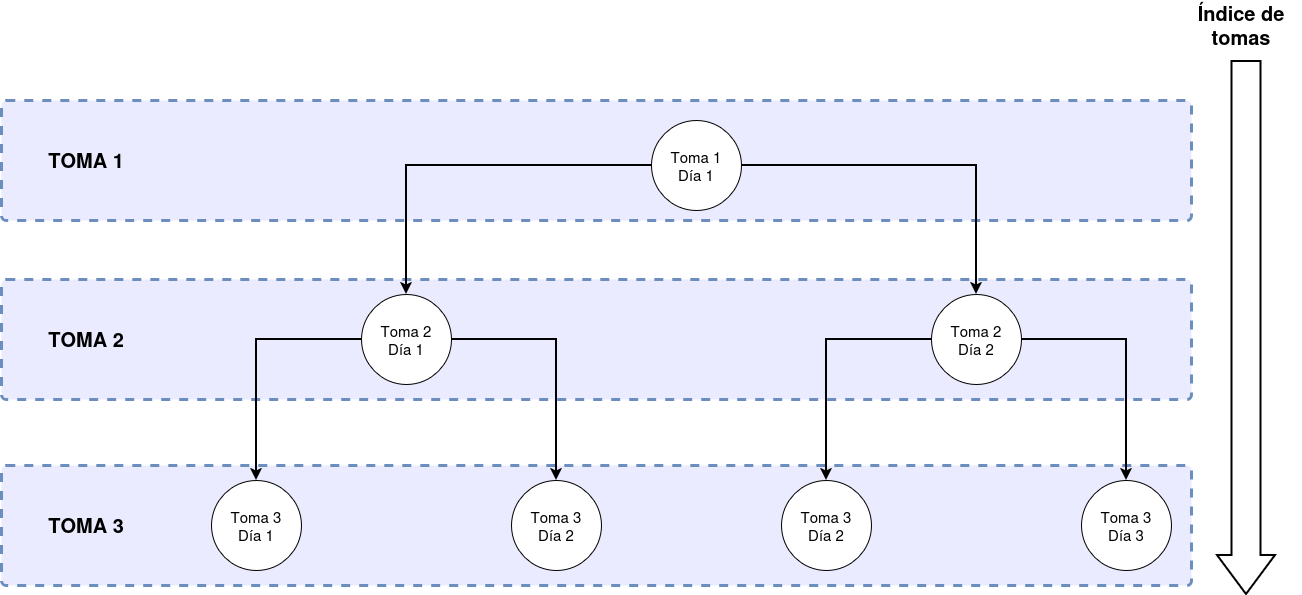

In [18]:
mejor_coste = float('inf') # Valor de coste infinito para iniciar el algoritmo
mejor_calendario = []

# Se crea un ID para cada toma
tomas_id_actores = [(id_tomas, conjunto_actores) for id_tomas, conjunto_actores in enumerate(lista_tomas)]
print(tomas_id_actores)

# Se ordenan las tomas de mayor participación de actores a tomas donde participan pocos actores
# Esto permite elevar el coste los más rápido posible y podar las ramas que no interesan lo antes posible
tomas_id_actores.sort(key=lambda x: len(x[1]), reverse=True)
print(tomas_id_actores)

[(0, {0, 1, 2, 3, 4}), (1, {2, 3, 4}), (2, {1, 4, 6}), (3, {0, 1, 6, 7}), (4, {1, 3, 7}), (5, {0, 1, 3, 4}), (6, {0, 1, 3, 4}), (7, {0, 1, 5}), (8, {0, 1, 3}), (9, {0, 1, 5, 8}), (10, {0, 1, 2, 4, 7}), (11, {0, 1, 2, 3, 5}), (12, {0, 3, 4}), (13, {0, 2, 5}), (14, {0, 1, 6}), (15, {9, 3}), (16, {0, 2}), (17, {2, 5}), (18, {0, 2}), (19, {0, 2, 3, 4}), (20, {5, 7}), (21, {0, 1, 2, 3}), (22, {0, 2}), (23, {2, 5}), (24, {0, 1, 3, 9}), (25, {0, 8, 2, 4}), (26, {3, 4}), (27, {0, 3}), (28, {0, 4, 5}), (29, {0, 3})]
[(0, {0, 1, 2, 3, 4}), (10, {0, 1, 2, 4, 7}), (11, {0, 1, 2, 3, 5}), (3, {0, 1, 6, 7}), (5, {0, 1, 3, 4}), (6, {0, 1, 3, 4}), (9, {0, 1, 5, 8}), (19, {0, 2, 3, 4}), (21, {0, 1, 2, 3}), (24, {0, 1, 3, 9}), (25, {0, 8, 2, 4}), (1, {2, 3, 4}), (2, {1, 4, 6}), (4, {1, 3, 7}), (7, {0, 1, 5}), (8, {0, 1, 3}), (12, {0, 3, 4}), (13, {0, 2, 5}), (14, {0, 1, 6}), (28, {0, 4, 5}), (15, {9, 3}), (16, {0, 2}), (17, {2, 5}), (18, {0, 2}), (20, {5, 7}), (22, {0, 2}), (23, {2, 5}), (26, {3, 4}), (2

In [8]:

# Construcción del árbol
def construir_arbol(indice_paso, calendario_actual, coste_actual):
    global mejor_coste, mejor_calendario

    # Poda de una rama no prometedora si el coste de la nueva rama que se esta evaluando es mayor que el mejor resultado se aborta el proceso
    # El float ('inf') garantiza que que no se cumpla la condicional al iniciar el algoritmo por primera vez
    if coste_actual >= mejor_coste:
        return

    if indice_paso == len(tomas_id_actores):
        mejor_coste = coste_actual
        mejor_calendario = copy.deepcopy(calendario_actual)
        print(f"Coste mínimo encontrado: {mejor_coste}")
        return

    # Extraemos el ID real de la toma y sus actores
    id_toma_real, toma_actual = tomas_id_actores[indice_paso]

    # Rama 1 días existentes
    for i in range(len(calendario_actual)):
        dia = calendario_actual[i]

        if len(dia['tomas']) < 6:
            actores_viejos = dia['actores']
            actores_nuevos = actores_viejos | toma_actual

            extra_coste = len(actores_nuevos) - len(actores_viejos)

            # Avanzar
            dia['tomas'].append(id_toma_real)
            dia['actores'] = actores_nuevos

            construir_arbol(indice_paso + 1, calendario_actual, coste_actual + extra_coste)

            # Retroceder
            dia['tomas'].pop()
            dia['actores'] = actores_viejos

    # Rama 2 Día nuevo
    coste_dia_nuevo = len(toma_actual)

    if coste_actual + coste_dia_nuevo < mejor_coste:
        nuevo_dia = {'tomas': [id_toma_real], 'actores': toma_actual}
        calendario_actual.append(nuevo_dia)

        # Avanzamos
        construir_arbol(indice_paso + 1, calendario_actual, coste_actual + coste_dia_nuevo)

        # Retroceder
        calendario_actual.pop()

In [9]:
comienzo = time.time()
# Ejecución del algoritmo
construir_arbol(0, [], 0)
final = time.time()

print(f"Duración total de la ejecución del algorimto es de: {(final - comienzo)/ 60} minutos")
print(f"El gasto mínimo absoluto es: {mejor_coste} sueldos de actores")
print("\nEl calendario de rodaje:")
for i, dia in enumerate(mejor_calendario):
    print(f"-> Día {i + 1}:")
    print(f"   Grabar Tomas: {dia['tomas']}")
    print(f"   Actores citados: {dia['actores']}")

Coste mínimo encontrado: 38
Coste mínimo encontrado: 37
Coste mínimo encontrado: 36
Coste mínimo encontrado: 35
Coste mínimo encontrado: 34
Coste mínimo encontrado: 33
Coste mínimo encontrado: 32
Coste mínimo encontrado: 31
Coste mínimo encontrado: 30
Coste mínimo encontrado: 29
Coste mínimo encontrado: 28
Coste mínimo encontrado: 27
Duración total de la ejecución del algorimto es de: 5.179903650283814 minutos
El gasto mínimo absoluto es: 27 sueldos de actores

El calendario de rodaje:
-> Día 1:
   Grabar Tomas: [0, 10, 11, 5, 9, 25]
   Actores citados: {0, 1, 2, 3, 4, 5, 7, 8}
-> Día 2:
   Grabar Tomas: [3, 2, 7, 14, 28, 20]
   Actores citados: {0, 1, 4, 5, 6, 7}
-> Día 3:
   Grabar Tomas: [6, 19, 21, 1, 12, 26]
   Actores citados: {0, 1, 2, 3, 4}
-> Día 4:
   Grabar Tomas: [24, 4, 8, 15, 27, 29]
   Actores citados: {0, 1, 3, 7, 9}
-> Día 5:
   Grabar Tomas: [13, 16, 17, 18, 22, 23]
   Actores citados: {0, 2, 5}


**Uso de la inteligencia artificial:**

Se ha utilizado la inteligencia artificial Gemini como soporte técnico para validar la elección del algoritmo de ramificación y poda, así como para optimizar el rendimiento del código.

